In [1]:
import torch
import torch.nn as nn
import torchaudio
import torch.nn.functional as F
import torchaudio.transforms as T
from typing import List, Dict, Optional, Iterable, Tuple

import os, re, random
import numpy as np
import sklearn
import itertools
import time

import pickle
from tqdm.auto import tqdm
from IPython.display import clear_output
import IPython.display as ipd
import gc
import matplotlib.pyplot as plt
import wandb

print(torch.__version__)
print(torchaudio.__version__)

import sys
sys.path.append("/home/iblitvinov@vniia.int/projects/Voice-commands-recognition")

torch.cuda.empty_cache()
gc.collect()

2.2.0
2.2.0


0

In [2]:
random.seed(123456)
np.random.seed(123456)
torch.manual_seed(123456)

use_cuda = torch.cuda.is_available()
device = "cuda:4"

def create_plots(signal, feature_map, name_fig, sample_rate=16000, 
                            signal_plot_dir='signal_plots', 
                            spec_plot_dir='spec_plots', 
                            mfcc_plot_dir='mfcc_plots',
                            notebook_path='/home/iblitvinov@vniia.int/projects/Voice-commands-recognition/notebooks'):
    
    signal = signal.cpu().numpy()

    num_frames = signal.size
    time_axis = torch.arange(0, num_frames) / sample_rate
    plt.plot(time_axis, signal, linewidth=1)
    plt.xlabel('Time')
    plt.title('Signal')
    plt.grid()
    plt.savefig(os.path.join(notebook_path, signal_plot_dir, name_fig))
    plt.clf()

    plt.specgram(signal, Fs=sample_rate)
    plt.xlabel('Time')
    plt.title('Spectrogram')
    plt.savefig(os.path.join(notebook_path, spec_plot_dir, name_fig))
    plt.clf()

    plt.imshow(feature_map.cpu(), interpolation='nearest', origin='lower', aspect='auto')
    plt.xlabel('Frame')
    plt.title('MFCC')
    plt.savefig(os.path.join(notebook_path, mfcc_plot_dir, name_fig))
    plt.clf()
    
def plot_waveform(waveform, mfcc, sample_rate=16000, title="Waveform", xlim=None):
    waveform = waveform.cpu().numpy()

    num_frames = waveform.size
    time_axis = torch.arange(0, num_frames) / sample_rate

    fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(16, 5))
    ax1.plot(time_axis, waveform, linewidth=1)
    ax1.set_xlabel('Time')
    ax1.set_title('Signal')

    ax2.specgram(waveform, Fs=sample_rate)
    ax2.set_xlabel('Time')
    ax2.set_title('Spectrogram')

    ax3.imshow(mfcc.cpu(), interpolation='nearest', origin='lower', aspect='auto')
    ax3.set_xlabel('Frame')
    ax3.set_title('MFCC')

    plt.suptitle(title)
    plt.show()
    
    ax1.grid(True)
    if xlim:
        ax1.set_xlim(xlim)
        
    fig.suptitle(title)
    plt.show()



In [32]:
data_path = '/home/iblitvinov@vniia.int/projects/stock_data_last_export/'
train_data_list = []
valid_data_list = []
new_data_list = []
with open(os.path.join(data_path, 'train_data_base_audio.pickle'), 'rb') as fh:
    train_data_list = pickle.load(fh)

with open(os.path.join(data_path, 'valid_data_base_audio.pickle'), 'rb') as fh:
    valid_data_list = pickle.load(fh)

len(train_data_list), len(valid_data_list)

(29721, 544)

### Translit labels to English

In [33]:
train_data_list

[{'name': 'user_950875817/Vverh_8_2.wav', 'label': 'Vverh'},
 {'name': 'user_950875817/Vverh_8_2_new_1.wav', 'label': 'Vverh'},
 {'name': 'user_950875817/Vverh_8_2_new_2.wav', 'label': 'Vverh'},
 {'name': 'user_950875817/Vverh_8_2_new_3.wav', 'label': 'Vverh'},
 {'name': 'user_950875817/Vverh_8_2_new_4.wav', 'label': 'Vverh'},
 {'name': 'user_950875817/Vverh_8_2_new_5.wav', 'label': 'Vverh'},
 {'name': 'user_950875817/Vverh_8_2_new_6.wav', 'label': 'Vverh'},
 {'name': 'user_950875817/Vverh_8_2_new_7.wav', 'label': 'Vverh'},
 {'name': 'user_950875817/Vverh_8_2_new_8.wav', 'label': 'Vverh'},
 {'name': 'user_950875817/Vverh_8_2_new_9.wav', 'label': 'Vverh'},
 {'name': 'user_950875817/Vverh_8_2_new_10.wav', 'label': 'Vverh'},
 {'name': 'user_950875817/Vverh_8_2_new_11.wav', 'label': 'Vverh'},
 {'name': 'user_950875817/Vverh_8_2_new_12.wav', 'label': 'Vverh'},
 {'name': 'user_950875817/Vverh_8_2_new_13.wav', 'label': 'Vverh'},
 {'name': 'user_950875817/Vverh_8_2_new_14.wav', 'label': 'Vverh

In [34]:
from transliterate import translit
def translit_func(data_list, isTrain=True):
    new_data_list = []
    for example in tqdm(data_list):
        new_label = translit(example['label'], reversed=True)
        new_name = translit(example['name'], reversed=True)
        # print( os.path.join(data_path, example['name']) )

        try:
            os.rename(os.path.join(data_path, example['name']), os.path.join(data_path, new_name))
            new_data_list.append({'name': new_name, 'label': new_label})
        except FileNotFoundError:
            print("Not opened")
            pass

    output_name = 'train_data_base_audio.pickle' if isTrain else 'valid_data_base_audio.pickle'
    with open(os.path.join(data_path, output_name), 'wb') as f:
        pickle.dump(new_data_list, f)

# translit_func(train_data_list)
# translit_func(valid_data_list, isTrain=False)

In [37]:
rus_classes = [
 'Домой',
 'Двигаться',
 'Найти',
 'Опустить',
 'Остановиться',
 'Открыть', 
 'Поднять',
 'Сменить',
 'Сохранить',
 'Старт',
 'Стоп',   
 'Влево',
 'Вниз',   
 'Вправо',
 'Вверх',  
 'Загрузить',
 'Захватить',   
 'Закрыть'
 ]

all_labels = set()
for example in train_data_list:
    all_labels.add(example['label'])
token_to_idx = {x: idx for idx, x in enumerate(all_labels)}
all_labels, token_to_idx

({'Domoj',
  "Dvigat'sja",
  'Najti',
  "Opustit'",
  "Ostanovit'sja",
  "Otkryt'",
  "Podnjat'",
  "Smenit'",
  "Sohranit'",
  'Start',
  'Stop',
  'Vlevo',
  'Vniz',
  'Vpravo',
  'Vverh',
  "Zagruzit'",
  "Zahvatit'",
  "Zakryt'"},
 {"Dvigat'sja": 0,
  'Vverh': 1,
  "Zagruzit'": 2,
  "Sohranit'": 3,
  "Ostanovit'sja": 4,
  'Vpravo': 5,
  'Najti': 6,
  'Vniz': 7,
  'Start': 8,
  "Zakryt'": 9,
  "Podnjat'": 10,
  "Zahvatit'": 11,
  'Stop': 12,
  "Smenit'": 13,
  "Otkryt'": 14,
  'Vlevo': 15,
  "Opustit'": 16,
  'Domoj': 17})

In [36]:
# print( len(data_list) )

# for sound in tqdm(data_list):
#     data_subpath = os.path.join(data_path, sound['name'])
#     try:
#         audio = torchaudio.load(data_subpath)
#         if audio[0].size(1) == 0:
#             print(audio[0].size(1))
#             data_list.remove(sound)
#             os.remove(data_subpath)
#             print(f'Removed {sound["name"]}')
#     except RuntimeError:
#         print(sound)
#         os.remove(data_subpath)
#         data_list.remove(sound)

# with open(os.path.join(data_path, 'data_base_audio.pickle'), 'wb') as f:
#     pickle.dump(data_list, f)
    
# print( len(data_list) )

In [7]:
# lengths_subsets = {'train': int(0.8 * len(data_list)), 'valid': round(0.1 * len(data_list)), 'test': round(0.1 * len(data_list))}
# train_vaild_subset, test_subset = torch.utils.data.random_split(data_list, 
#                                                                 [lengths_subsets['train']+lengths_subsets['valid'], lengths_subsets['test']])
# train_subset, valid_subset = torch.utils.data.random_split(train_vaild_subset, 
#                                                                 [lengths_subsets['train'], lengths_subsets['valid']])
# lengths_subsets

{'train': 28136, 'valid': 3517, 'test': 3517}

In [38]:
import gc

class Sound_dataset_commands(torch.utils.data.Dataset):
    def __init__(self, rootdir, subset, transform=None):
        self.transform = transform
        self.rootdir = rootdir
        self.subset = subset
        self.n_subset = len(self.subset)
        self.token_to_idx = {x: idx for idx, x in enumerate(all_labels)}
        self.idx_to_token = {idx: x for idx, x in enumerate(all_labels)}

        self.preprocessed_dataset = self._preprocessing()
        torch.cuda.empty_cache()
        gc.collect()
        self.preprocessed_dataset = self.preprocessed_dataset

    def _preprocessing(self):
        dataset = []
        for sound in tqdm(self.subset):
            name, label = sound.values()
            signal, _ = torchaudio.load(os.path.join(self.rootdir, name))
            signal = signal[0]
            if self.transform:
                feature_map = self.transform(signal)
#               signal = self.transform.transforms[0](signal)
            idx_label = self.token_to_idx[label]
            dataset.append((feature_map.to(device), idx_label, signal.to(device)))
        
        return dataset

    def __getitem__(self, index):
        feature_map, idx_label, signal = self.preprocessed_dataset[index]
        name, label = self.subset[index].values()

        return feature_map, idx_label, signal, name, label

    def __len__(self):
        return len(self.subset)

In [39]:
# 30мс 10мс шаг
n_fft = 480
win_length = None
hop_length = 160
mfcc_transform = T.MFCC(
    sample_rate=16000,
    n_mfcc=32,
    melkwargs={
        "n_fft": n_fft,
        "n_mels": 64,
        "hop_length": hop_length
    },
)

transform = mfcc_transform
data_set = {
            'train': Sound_dataset_commands(rootdir=data_path, subset=train_data_list, transform=transform),
            'valid': Sound_dataset_commands(rootdir=data_path, subset=valid_data_list, transform=transform),
            # 'test': Sound_dataset_commands(rootdir=data_path, subset=test_subset, transform=transform)
        }
c = itertools.cycle(data_set['train'])

  0%|          | 0/29721 [00:00<?, ?it/s]

  0%|          | 0/544 [00:00<?, ?it/s]

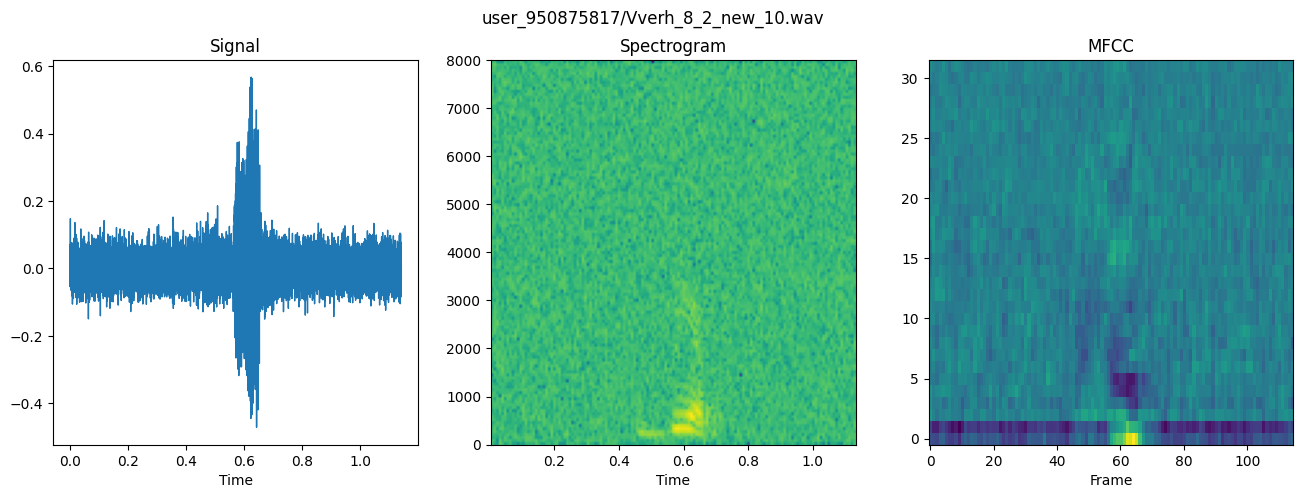

In [51]:
mfcc, label, signal, xname, label = next(c)
plot_waveform(signal, mfcc, sample_rate=16000, title=f'{xname}')
ipd.Audio(signal.cpu(), rate=16000)

In [52]:
from models.model import Speech_recognition_model
import yaml

# Сделать разные конфиги
params = None
with open("../configs/model_params_res.yaml", "r") as stream:
    try:
        params = yaml.safe_load(stream)
    except yaml.YAMLError as exc:
        print(exc)

In [53]:
params

{'Architecture': {'CNN_params': {'in_channels': 1,
   'out_channels': 64,
   'kernel_size': 3,
   'stride': 2,
   'padding': 1},
  'ResCNN_params': {'in_channels': 64,
   'out_channels': 64,
   'kernel_size': 3,
   'stride': 1,
   'dropout': 0.255,
   'n_feats': 16,
   'padding': 1,
   'n_cnn_layers': 4},
  'Fully_connected_params': {'in_features': 1024, 'out_features': 512},
  'RNN_params': {'input_size': 512,
   'hidden_size': 512,
   'num_layers': 2,
   'bidirectional': True,
   'dropout': 0.27,
   'rnn_type': 'lstm'},
  'Attention_params': {'feature_dim': 512, 'step_dim': 4},
  'Classifier_params': {'in_features': 512,
   'out_features': 256,
   'dropout': 0.4,
   'n_class': 18}},
 'Settings': {'Optimizer_Scheduler': {'lr_rate': '5e-4',
   'weight_decay': 0.0005,
   'amsgrad': False,
   'max_lr': 0.07,
   'div_factor': 125,
   'max_norm': 1.4},
  'Other': {'epochs': 100, 'batch_size': 64}}}

In [55]:
def collate_fn(batch):
    X = torch.nn.utils.rnn.pad_sequence([sample[0].transpose(0, 1) for sample in batch], batch_first=True, padding_value=0).unsqueeze(1)
    y = torch.Tensor([sample[1] for sample in batch]).to(torch.long).to(device)

    signal = [sample[2] for sample in batch]
    name = [sample[3] for sample in batch]
    label = [sample[4] for sample in batch]

    return X, y, signal, name, label

batch_size = params['Settings']['Other']['batch_size']
epochs = params['Settings']['Other']['epochs']
max_norm = params['Settings']['Optimizer_Scheduler']['max_norm']
loaders = {
        'train': torch.utils.data.DataLoader(data_set['train'], batch_size=batch_size, shuffle=True, collate_fn=collate_fn),
        'valid': torch.utils.data.DataLoader(data_set['valid'], batch_size=batch_size, shuffle=True, collate_fn=collate_fn),
        # 'test': torch.utils.data.DataLoader(data_set['test'], batch_size=1, shuffle=False, collate_fn=collate_fn)
        }

In [56]:
!wandb login --relogin a4fc0db907801a21173615cb84708e1774b986a4
wandb.init(project="Commands Recognition", name="training_2024", config=params)
columns = ["name", "signal_plot", "spec_plot", "mfcc_plot", "pred_label", "true_label"]
valid_table = wandb.Table(columns=columns)

wandb: Appending key for api.wandb.ai to your netrc file: /home/iblitvinov@vniia.int/.netrc


Failed to detect the name of this notebook, you can set it manually with the WANDB_NOTEBOOK_NAME environment variable to enable code saving.
wandb: Currently logged in as: litvan. Use `wandb login --relogin` to force relogin


In [57]:
from models.model import Speech_recognition_model

def create_model_utils(params, weight_decay, amsgrad, max_lr, div_factor, epochs, steps_per_epoch, tl=False, tl_type='freeze', tl_low_lr=1e-8, load_path=None):
    tr_loss = []
    cv_loss = []
    tr_acc = []
    cv_acc = []
    epoch = 0
    model = Speech_recognition_model(**params).to(device)
    criterion = torch.nn.CrossEntropyLoss(reduction='mean').to(device)

    optimizer = torch.optim.Adam(model.parameters(),
                                lr=max_lr/div_factor,
                                weight_decay=weight_decay,
                                amsgrad=amsgrad)

    scheduler = torch.optim.lr_scheduler.OneCycleLR(optimizer, max_lr=max_lr,
                            steps_per_epoch=steps_per_epoch,
                            epochs=epochs, div_factor=div_factor)

    if tl:
        model.load_state_dict(torch.load('../../checkpoints/sub_model_asr_2.pth', map_location=device), strict=False)
        if tl_type == 'freeze':
            for param in list(model.parameters())[:28]: #28
                param.requires_grad = False

        elif tl_type == 'low_step':
            optimizer = torch.optim.Adam(params=[
                                            {"params": list(model.parameters())[28:]},
                                            {"params": list(model.parameters())[:28], "lr": tl_low_lr}
                                        ], lr=max_lr/div_factor, weight_decay=weight_decay, amsgrad=amsgrad)

        elif tl_type == 'non_freeze':
            pass

    if load_path is not None:
        checkpoint = torch.load(load_path)

        model.load_state_dict(checkpoint['state_dict'], map_location=device)
        optimizer.load_state_dict(checkpoint['optim_dict'])
        scheduler.load_state_dict(checkpoint['scheduler_dict'])
        tr_loss = checkpoint['tr_loss']
        cv_loss = checkpoint['cv_loss']
        epoch = checkpoint['epoch']
        tr_acc = checkpoint['tr_accuracy']
        cv_acc = checkpoint['cv_accuracy']
    
    return model, criterion, optimizer, scheduler, tr_loss, cv_loss, epoch, tr_acc, cv_acc

epochs = 1000
model, criterion, optimizer, scheduler, tr_loss, cv_loss, epoch, tr_acc, cv_acc = create_model_utils(params['Architecture'],
                                                                                                    params['Settings']['Optimizer_Scheduler']['weight_decay'],
                                                                                                    params['Settings']['Optimizer_Scheduler']['amsgrad'],
                                                                                                    params['Settings']['Optimizer_Scheduler']['max_lr'],
                                                                                                    params['Settings']['Optimizer_Scheduler']['div_factor'],
                                                                                                    epochs,
                                                                                                    len(loaders['train']), tl=False)

Not setting weights for type <class 'torch.nn.modules.dropout.Dropout'>
Not setting weights for type <class 'torch.nn.modules.dropout.Dropout'>
Not setting weights for type <class 'torch.nn.modules.normalization.LayerNorm'>
Not setting weights for type <class 'models.cnn.CNNLayerNorm'>
Not setting weights for type <class 'torch.nn.modules.normalization.LayerNorm'>
Not setting weights for type <class 'models.cnn.CNNLayerNorm'>
Not setting weights for type <class 'models.cnn.ResidualCNN'>
Not setting weights for type <class 'torch.nn.modules.dropout.Dropout'>
Not setting weights for type <class 'torch.nn.modules.dropout.Dropout'>
Not setting weights for type <class 'torch.nn.modules.normalization.LayerNorm'>
Not setting weights for type <class 'models.cnn.CNNLayerNorm'>
Not setting weights for type <class 'torch.nn.modules.normalization.LayerNorm'>
Not setting weights for type <class 'models.cnn.CNNLayerNorm'>
Not setting weights for type <class 'models.cnn.ResidualCNN'>
Not setting weig

In [58]:
model

Speech_recognition_model(
  (cnn): Conv2d(1, 64, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1))
  (rescnn_layers): Sequential(
    (0): ResidualCNN(
      (cnn1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (cnn2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (dropout1): Dropout(p=0.255, inplace=False)
      (dropout2): Dropout(p=0.255, inplace=False)
      (layer_norm1): CNNLayerNorm(
        (layer_norm): LayerNorm((16,), eps=1e-05, elementwise_affine=True)
      )
      (layer_norm2): CNNLayerNorm(
        (layer_norm): LayerNorm((16,), eps=1e-05, elementwise_affine=True)
      )
    )
    (1): ResidualCNN(
      (cnn1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (cnn2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (dropout1): Dropout(p=0.255, inplace=False)
      (dropout2): Dropout(p=0.255, inplace=False)
      (layer_norm1): CNNLayerNorm(
        (layer_norm): LayerN

In [59]:
def get_nn_params_stat(model: nn.Module) -> None:
    
    def iter_mul(inputs: Iterable) -> int:
        mul = 1
        for elem in inputs:
            mul *= elem
        return mul
    
    shapes = [p.shape for p in model.parameters()]
    for p_shape in shapes:
        print(p_shape)
    total_count = sum([iter_mul(p_shape) for p_shape in shapes])
    print('Total params:', total_count)
    print('Model param size in Mb:', total_count * 4 / (2 ** 20))

get_nn_params_stat(model)

torch.Size([64, 1, 3, 3])
torch.Size([64])
torch.Size([64, 64, 3, 3])
torch.Size([64])
torch.Size([64, 64, 3, 3])
torch.Size([64])
torch.Size([16])
torch.Size([16])
torch.Size([16])
torch.Size([16])
torch.Size([64, 64, 3, 3])
torch.Size([64])
torch.Size([64, 64, 3, 3])
torch.Size([64])
torch.Size([16])
torch.Size([16])
torch.Size([16])
torch.Size([16])
torch.Size([64, 64, 3, 3])
torch.Size([64])
torch.Size([64, 64, 3, 3])
torch.Size([64])
torch.Size([16])
torch.Size([16])
torch.Size([16])
torch.Size([16])
torch.Size([64, 64, 3, 3])
torch.Size([64])
torch.Size([64, 64, 3, 3])
torch.Size([64])
torch.Size([16])
torch.Size([16])
torch.Size([16])
torch.Size([16])
torch.Size([512, 1024])
torch.Size([512])
torch.Size([2048, 512])
torch.Size([2048, 512])
torch.Size([2048])
torch.Size([2048])
torch.Size([2048, 512])
torch.Size([2048, 512])
torch.Size([2048])
torch.Size([2048])
torch.Size([2048, 1024])
torch.Size([2048, 512])
torch.Size([2048])
torch.Size([2048])
torch.Size([2048, 1024])
torch.S

In [60]:
def get_accuracy(y_pred, y_test):
    correct_results_sum = (y_pred == y_test).sum().float()
    acc = correct_results_sum/(y_test.size(0))
    
    return acc

In [61]:
from torchmetrics import  ConfusionMatrix
import seaborn as sn
import pandas as pd

signal_plot_dir='signal_plots'
spec_plot_dir='spec_plots'
mfcc_plot_dir='mfcc_plots'
notebook_path = '/home/iblitvinov@vniia.int/projects/Voice-commands-recognition/notebooks'

def run_one_epoch(epoch, cross_valid=False, print_freq=5):
    start = time.time()
    total_loss = 0
    total_accuracy = 0
    total_n = 0

    data_loader = loaders['train'] if not cross_valid else loaders['valid']

    true_labels = []
    pred_labels = []
    
    for data in tqdm(data_loader):
        feature_map, idx_label, signal, name, label = data

        outputs = model(feature_map)
        loss = criterion(outputs, idx_label)

        total_n += 1

        if not cross_valid:
            optimizer.zero_grad()
            loss.backward()
            grad_norm = torch.nn.utils.clip_grad_norm_(model.parameters(),
                                                        max_norm)
            optimizer.step()

        total_loss += loss.item()
        preds = torch.argmax(F.softmax(outputs, dim=1), dim=1)
        accuracy = get_accuracy(preds, idx_label)
        total_accuracy += accuracy
        optim_state = optimizer.state_dict()
        curr_lr = optim_state['param_groups'][0]['lr']

        if total_n % print_freq == 0:
                print('Epoch {0} | Iter {1} | Average Loss {2:.3f} | '
                    'Current Loss {3:.6f} | Current accuracy {4:.6f} | Current lr {5:.5f} | {6:.1f} ms/batch'.format(
                        epoch + 1, total_n + 1, total_loss / (total_n + 1),
                        loss.item(), accuracy, curr_lr, 1000 * (time.time() - start) / (total_n + 1)),
                    flush=True)

        if cross_valid:

            name_fig = f'{name[0].replace("/", "_").split(".")[0]}.png'
            create_plots(signal[0], feature_map[0][0], name_fig, notebook_path=notebook_path)    
            temp = [name[0], 
                # wandb.Audio(signal[0].cpu(), sample_rate=16000), 
                wandb.Image(os.path.join( notebook_path, signal_plot_dir, name_fig )),
                wandb.Image(os.path.join( notebook_path, spec_plot_dir, name_fig )),
                wandb.Image(os.path.join( notebook_path, mfcc_plot_dir, name_fig )),
                preds[0],
                idx_label[0]]
            valid_table.add_row(*temp)

            true_labels.extend(idx_label.tolist())
            pred_labels.extend(preds.tolist())

            wandb.log({"conf_mat" : wandb.plot.confusion_matrix(probs=None,
                            y_true=true_labels, preds=pred_labels,
                            class_names=rus_classes)})

    return total_loss / total_n, total_accuracy / total_n

In [62]:
checkpoint = False
visdom = True
save_folder = '../checkpoints/'
best_val_loss = 10

wandb.watch(model, log_freq=1, log='all')
for epoch in tqdm(np.arange(epoch, epochs)):
    # print('Cross validation...')
    # model.eval()  # Turn off Batchnorm & Dropout
    # cv_avg_loss, cv_avg_acc = run_one_epoch(epoch, cross_valid=True)

    print("Training...")
    model.train()
    start = time.time()
    tr_avg_loss, tr_avg_acc = run_one_epoch(epoch)
    tr_loss.append(tr_avg_loss)
    tr_acc.append(tr_avg_acc)

    print('-' * 85)
    print('Train Summary | End of Epoch {0} | Time {1:.2f}s | '
                'Train Loss {2:.3f} | Accuracy {3:.3f}'.format(
                    epoch + 1, time.time() - start, tr_avg_loss, tr_avg_acc))
    print('-' * 85)

    if checkpoint:
        file_path = os.path.join(
        save_folder, 'epoch_{0}_loss_{1:.4f}.pth.tar'.format(epoch + 1, cv_avg_loss))
        torch.save(model.serialize(model, optimizer, scheduler, epoch + 1,
                                        tr_loss=tr_loss,
                                        cv_loss=cv_loss),
                file_path)
        print('Saving checkpoint model to %s' % file_path)

    print('Cross validation...')
    model.eval()  # Turn off Batchnorm & Dropout
    cv_avg_loss, cv_avg_acc = run_one_epoch(epoch, cross_valid=True)
    cv_loss.append(cv_avg_loss)
    cv_acc.append(cv_avg_acc)
    
    print('-' * 185)
    print('Valid Summary | End of Epoch {0} | Time {1:.2f}s | '
            'Valid Loss {2:.3f} | Accuracy {3:.3f}'.format(
                epoch + 1, time.time() - start, cv_avg_loss, cv_avg_acc))
    print('-' * 185)

    # Save the best model
    if cv_avg_loss < best_val_loss:
        best_val_loss = cv_avg_loss
        model_path = 'epoch_{0}_loss_{1:.4f}_best.pth.tar'.format(epoch + 1, cv_avg_loss)
        file_path = os.path.join(save_folder, model_path)
        torch.save(model.serialize(model, optimizer, scheduler, epoch + 1,
                                    tr_losses=tr_loss,
                                    cv_losses=cv_loss,
                                    tr_accuracy=tr_acc,
                                    cv_accuracy=cv_acc),
                file_path)
        print("Find better validated model, saving to %s" % file_path)

    wandb.log({"epoch": epoch})
    wandb.log({"train_loss": tr_avg_loss})
    wandb.log({"valid_loss": cv_avg_loss})
    wandb.log({"train_accuracy": tr_avg_acc})
    wandb.log({"valid_accuracy": cv_avg_acc})
    wandb.run.log({"valid_inference" : valid_table}) 

  0%|          | 0/1000 [00:00<?, ?it/s]

Cross validation...


  0%|          | 0/9 [00:00<?, ?it/s]

/home/iblitvinov@vniia.int/Miniconda/envs/common_venv/lib/python3.10/site-packages/matplotlib/axes/_axes.py:7944: RuntimeWarning: divide by zero encountered in log10
  Z = 10. * np.log10(spec)


Training...


...

wandb: ERROR Error while calling W&B API: An internal error occurred. Please contact support. (<Response [500]>)


Epoch 1 | Iter 126 | Average Loss 3.331 | Current Loss 2.918688 | Current accuracy 0.140625 | Current lr 0.00056 | 241.3 ms/batch
Epoch 1 | Iter 151 | Average Loss 3.242 | Current Loss 2.808596 | Current accuracy 0.093750 | Current lr 0.00056 | 241.0 ms/batch


KeyboardInterrupt: 

<Figure size 640x480 with 0 Axes>

wandb: ERROR Error while calling W&B API: An internal error occurred. Please contact support. (<Response [500]>)
wandb: ERROR Error while calling W&B API: An internal error occurred. Please contact support. (<Response [500]>)
wandb: ERROR Error while calling W&B API: An internal error occurred. Please contact support. (<Response [500]>)
